<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/analisis_del_dato/analisis4_pca_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Script 4 — PCA y K-Means a nivel de canción
**Input:** `dataset_canciones_modelos.csv` (output del Script 3)  
**Output:** `dataset_canciones_clusters.csv` — canciones con cluster asignado  



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

COLORES_BASE = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange',
                'mediumpurple', 'goldenrod', 'slategray']

df = pd.read_csv('dataset_canciones_modelos.csv')
df_raw = pd.read_csv('dataset_canciones_limpio.csv')

print(f'Dataset modelos: {df.shape}')
print(f'Dataset raw:     {df_raw.shape}')
print(f'Nulos dataset modelos: {df.isnull().sum().sum()}')
df.head()

Dataset modelos: (1185, 22)
Dataset raw:     (1185, 16)
Nulos dataset modelos: 0


,year,popularity,duration_sec,artist_popularity,years_since_release,explicit,is_urbano_latino,is_lanzamiento_reciente,is_artista_top,genero_electronica,genero_flamenco_raices,genero_internacional,genero_otros,genero_pop_espanol,genero_rock_indie,genero_unknown,genero_urbano_latino,temporada_invierno,temporada_otono,temporada_primavera,temporada_sin_fecha,temporada_verano
0,2010,0.166213,0.497822,-0.399913,-0.20923,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,2010,0.529898,0.064570,0.397996,-0.20923,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,2010,1.205315,-0.310980,0.704885,-0.20923,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,2010,-0.457249,0.188458,-0.215780,-0.20923,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,2010,-0.768980,1.118214,-0.461291,-0.20923,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


In [ ]:
# Seleccionamos las features para PCA (excluimos 'year' que es variable temporal, no de perfil)
cols_excluir = ['year']
feature_cols = [c for c in df.columns if c not in cols_excluir]

X = df[feature_cols].values

print(f'Features para PCA: {len(feature_cols)}')
print(feature_cols)

Features para PCA: 21
['popularity', 'duration_sec', 'artist_popularity', 'years_since_release', 'explicit', 'is_urbano_latino', 'is_lanzamiento_reciente', 'is_artista_top', 'genero_electronica', 'genero_flamenco_raices', 'genero_internacional', 'genero_otros', 'genero_pop_espanol', 'genero_rock_indie', 'genero_unknown', 'genero_urbano_latino', 'temporada_invierno', 'temporada_otono', 'temporada_primavera', 'temporada_sin_fecha', 'temporada_verano']


---
## 2. PCA — Varianza explicada

Componentes para explicar el 80% de la varianza: 6
Componentes para explicar el 90% de la varianza: 8
Varianza explicada por PC1 y PC2: 51.6%


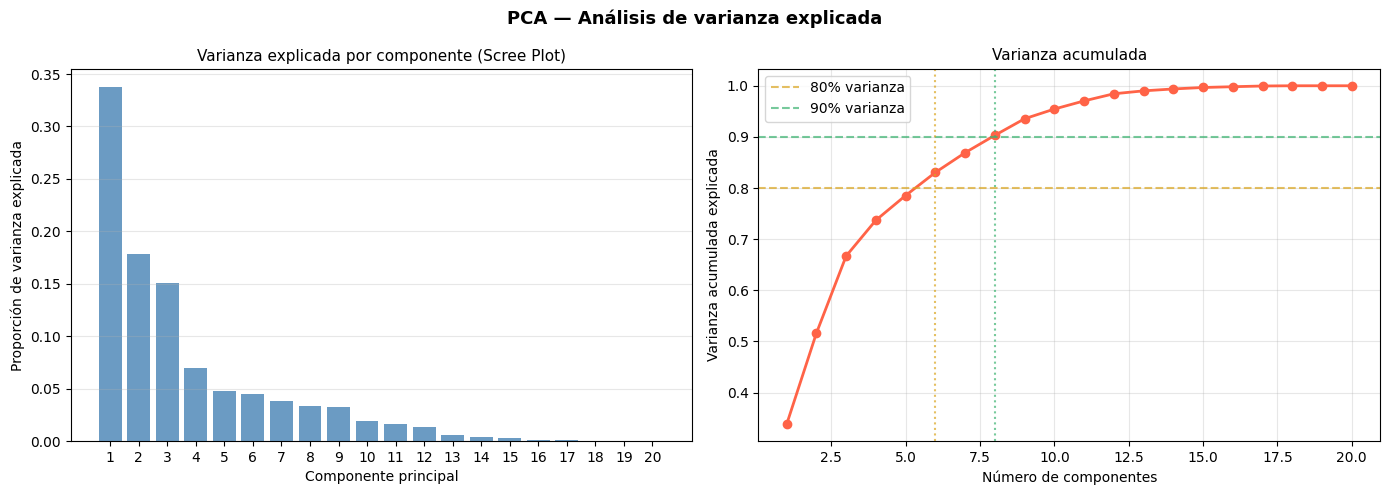


Decisión: se usan 6 componentes para K-Means (80% varianza explicada)
Se usan 2 componentes para visualización (PC1+PC2 = 51.6%)


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

varianza_exp = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza_exp)

n_80 = np.argmax(varianza_acum >= 0.80) + 1
n_90 = np.argmax(varianza_acum >= 0.90) + 1

print(f'Componentes para explicar el 80% de la varianza: {n_80}')
print(f'Componentes para explicar el 90% de la varianza: {n_90}')
print(f'Varianza explicada por PC1 y PC2: {varianza_acum[1]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Análisis de varianza explicada', fontsize=13, fontweight='bold')

n_show = min(20, len(varianza_exp))

# Scree plot con color coherente
axes[0].bar(range(1, n_show + 1), varianza_exp[:n_show], color='steelblue', alpha=0.8)
axes[0].set_title('Varianza explicada por componente (Scree Plot)', fontsize=11)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza explicada')
axes[0].set_xticks(range(1, n_show + 1))
axes[0].grid(axis='y', alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, n_show + 1), varianza_acum[:n_show],
             marker='o', linewidth=2, color='tomato')
axes[1].axhline(y=0.80, color='goldenrod', linestyle='--', alpha=0.7, label='80% varianza')
axes[1].axhline(y=0.90, color='mediumseagreen', linestyle='--', alpha=0.7, label='90% varianza')
axes[1].axvline(x=n_80, color='goldenrod', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_90, color='mediumseagreen', linestyle=':', alpha=0.7)
axes[1].set_title('Varianza acumulada', fontsize=11)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada explicada')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nDecisión: se usan {n_80} componentes para K-Means (80% varianza explicada)')
print(f'Se usan 2 componentes para visualización (PC1+PC2 = {varianza_acum[1]:.1%})')

---
## 3. PCA en 2 componentes — Proyección y loadings

In [ ]:
# PCA con 2 componentes para visualización
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['year'] = df['year'].values

# Recuperamos variables del dataset raw para visualización
if len(df_raw) == len(df_pca):
    df_pca['genre_group_agrupado'] = df_raw['genre_group_agrupado'].values if 'genre_group_agrupado' in df_raw.columns else 'unknown'

print(f'Varianza explicada PC1: {pca_2d.explained_variance_ratio_[0]:.1%}')
print(f'Varianza explicada PC2: {pca_2d.explained_variance_ratio_[1]:.1%}')
print(f'Varianza total (PC1+PC2): {sum(pca_2d.explained_variance_ratio_):.1%}')

Varianza explicada PC1: 33.8%
Varianza explicada PC2: 17.8%
Varianza total (PC1+PC2): 51.6%


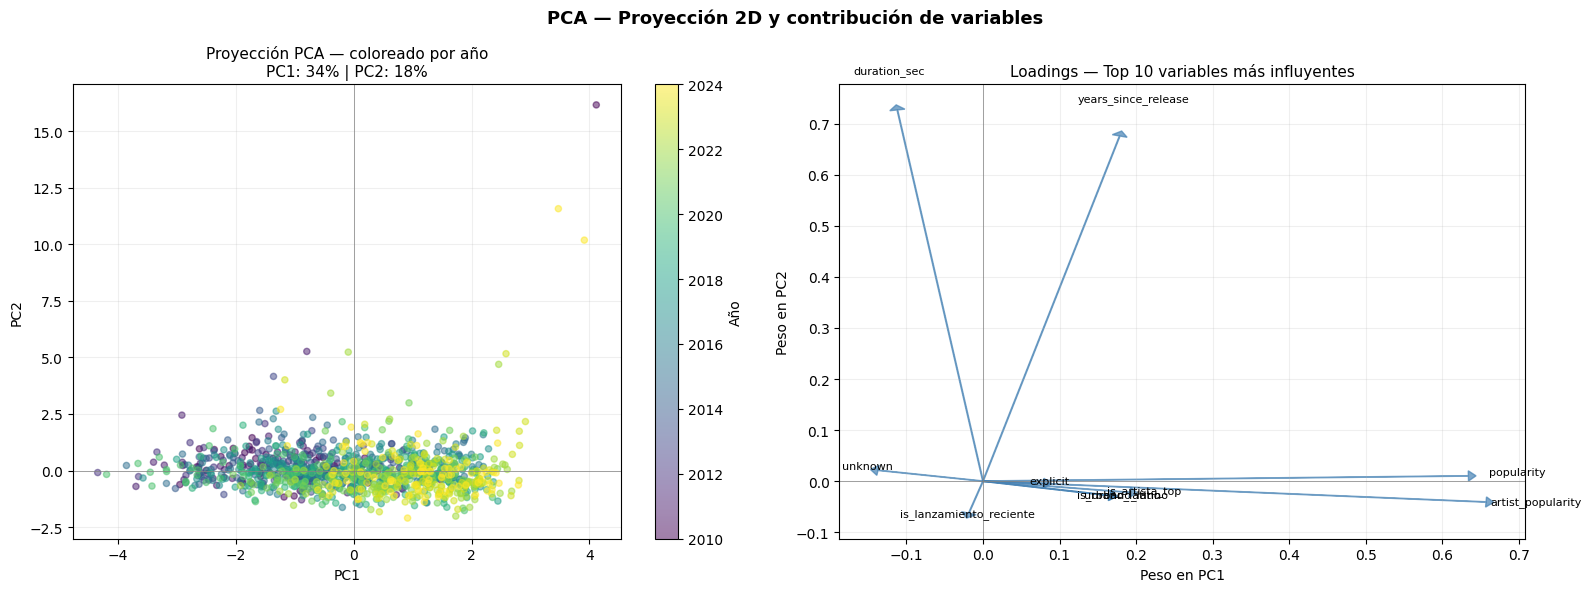


Top 10 variables por peso absoluto en PC1 o PC2:
                           PC1    PC2
duration_sec            -0.112  0.727
years_since_release      0.179  0.676
artist_popularity        0.657 -0.041
popularity               0.634  0.010
is_artista_top           0.192 -0.022
is_urbano_latino         0.165 -0.028
genero_urbano_latino     0.165 -0.028
genero_unknown          -0.137  0.021
explicit                 0.079 -0.004
is_lanzamiento_reciente -0.018 -0.063


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA — Proyección 2D y contribución de variables', fontsize=13, fontweight='bold')

# scatter coloreado por año
scatter = axes[0].scatter(
    df_pca['PC1'], df_pca['PC2'],
    c=df_pca['year'], cmap='viridis', alpha=0.5, s=20
)
plt.colorbar(scatter, ax=axes[0], label='Año')
axes[0].set_title(f'Proyección PCA — coloreado por año\n'
                  f'PC1: {pca_2d.explained_variance_ratio_[0]:.0%} | '
                  f'PC2: {pca_2d.explained_variance_ratio_[1]:.0%}', fontsize=11)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(0, color='grey', linewidth=0.5)
axes[0].grid(alpha=0.2)

# loadings: top 10 variables con mayor peso
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
loadings['max_abs'] = loadings.abs().max(axis=1)
top_loadings = loadings.nlargest(10, 'max_abs')

for _, row in top_loadings.iterrows():
    axes[1].arrow(0, 0, row['PC1'], row['PC2'],
                  head_width=0.02, head_length=0.01,
                  fc='steelblue', ec='steelblue', alpha=0.7)
    axes[1].text(row['PC1'] * 1.1, row['PC2'] * 1.1, _.replace('genero_', '').replace('temporada_', 'temp_'),
                 fontsize=8, ha='center')

axes[1].set_title('Loadings — Top 10 variables más influyentes', fontsize=11)
axes[1].set_xlabel('Peso en PC1')
axes[1].set_ylabel('Peso en PC2')
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].axvline(0, color='grey', linewidth=0.5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('\nTop 10 variables por peso absoluto en PC1 o PC2:')
print(top_loadings[['PC1', 'PC2']].round(3))

---
## 5. K-Means — Selección del número óptimo de clusters

PCA para K-Means: 6 componentes — varianza explicada: 83.0%
  k=2: inercia=4214.2, silueta=0.2926
  k=3: inercia=3303.3, silueta=0.2994
  k=4: inercia=2869.4, silueta=0.2528
  k=5: inercia=2503.4, silueta=0.2121
  k=6: inercia=2248.5, silueta=0.2114
  k=7: inercia=2090.6, silueta=0.2035
  k=8: inercia=1954.5, silueta=0.1975
  k=9: inercia=1843.1, silueta=0.1885

k óptimo por silueta: 2


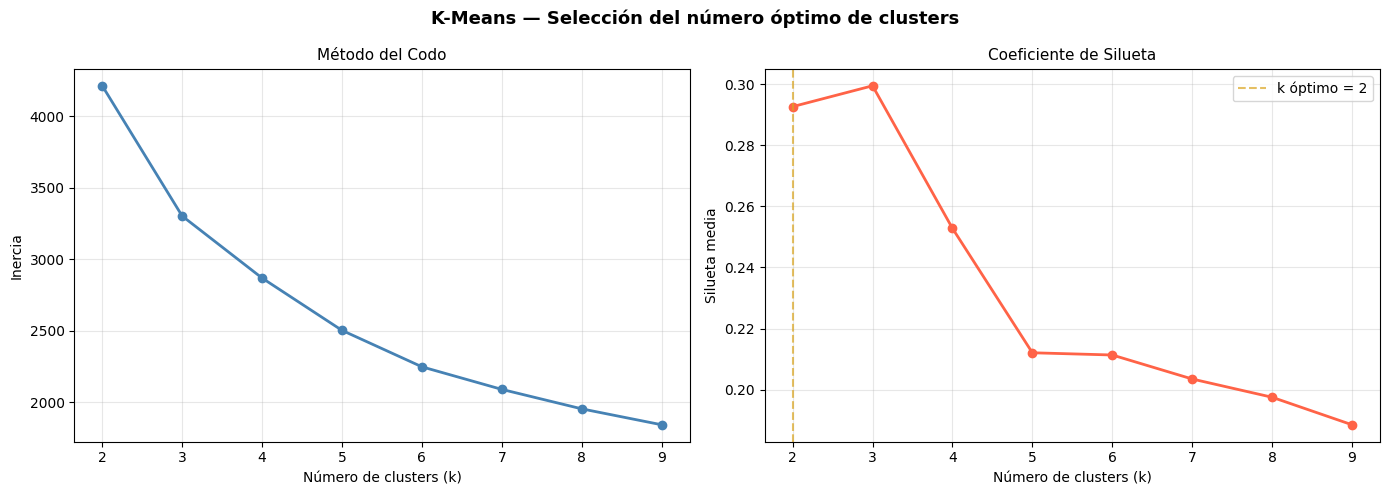

In [ ]:
pca_kmeans = PCA(n_components=n_80, random_state=RANDOM_STATE)
X_pca_kmeans = pca_kmeans.fit_transform(X)
print(f'PCA para K-Means: {n_80} componentes — varianza explicada: {sum(pca_kmeans.explained_variance_ratio_):.1%}')

inercias = []
siluetas = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_pca_kmeans)
    inercias.append(kmeans.inertia_)
    sil = silhouette_score(X_pca_kmeans, labels)
    siluetas.append(sil)
    print(f'  k={k}: inercia={kmeans.inertia_:.1f}, silueta={sil:.4f}')

k_opt = 2
print(f'\nk óptimo por silueta: {k_opt}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means — Selección del número óptimo de clusters', fontsize=13, fontweight='bold')

axes[0].plot(list(k_range), inercias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Método del Codo', fontsize=11)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), siluetas, marker='o', linewidth=2, color='tomato')
axes[1].axvline(x=k_opt, color='goldenrod', linestyle='--', alpha=0.7,
                label=f'k óptimo = {k_opt}')
axes[1].set_title('Coeficiente de Silueta', fontsize=11)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silueta media')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. K-Means — Modelo final y asignación de clusters

In [ ]:
# entrenamos con k óptimo
K_FINAL = k_opt

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca_kmeans)

# añadimos etiquetas al dataset
df['cluster'] = cluster_labels
df_pca['cluster'] = cluster_labels

# métricas del modelo final
sil_final = silhouette_score(X_pca_kmeans, cluster_labels)
print(f'K-Means final: k={K_FINAL}')
print(f'Inercia:             {kmeans_final.inertia_:.2f}')
print(f'Coeficiente silueta: {sil_final:.4f}')
print(f'\nDistribución de canciones por cluster:')
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means final: k=2
Inercia:             4214.22
Coeficiente silueta: 0.2926

Distribución de canciones por cluster:
0    630
1    555
Name: count, dtype: int64


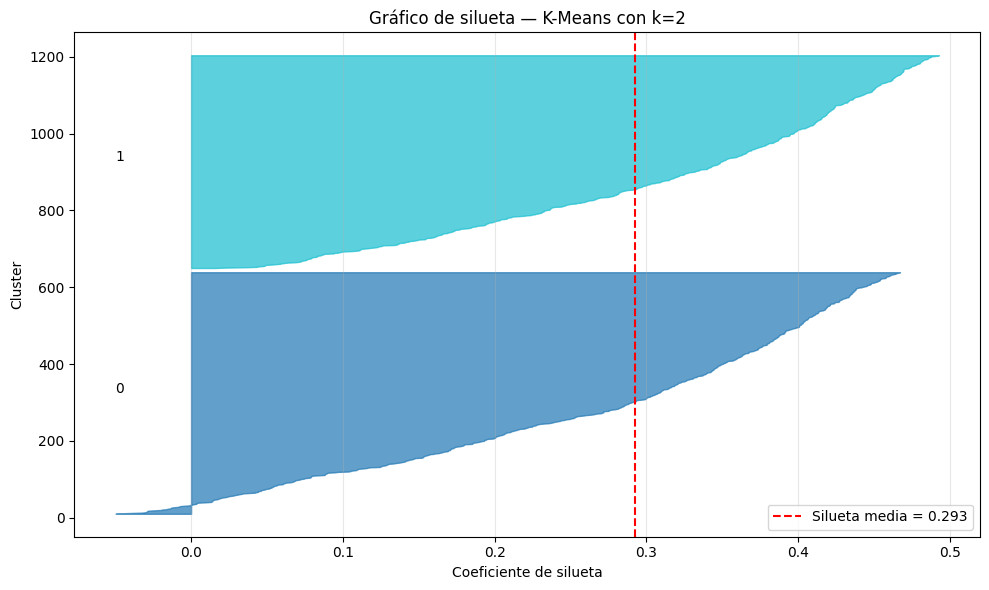

In [ ]:
# gráfico de silueta por muestra (diagnóstico de calidad de clustering)
fig, ax = plt.subplots(figsize=(10, 6))

sil_values = silhouette_samples(X_pca_kmeans, cluster_labels)
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    sil_i = np.sort(sil_values[cluster_labels == i])
    size_i = sil_i.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', label=f'Silueta media = {sil_final:.3f}')
ax.set_title(f'Gráfico de silueta — K-Means con k={K_FINAL}', fontsize=12)
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Cluster')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Visualización de clusters en espacio PCA

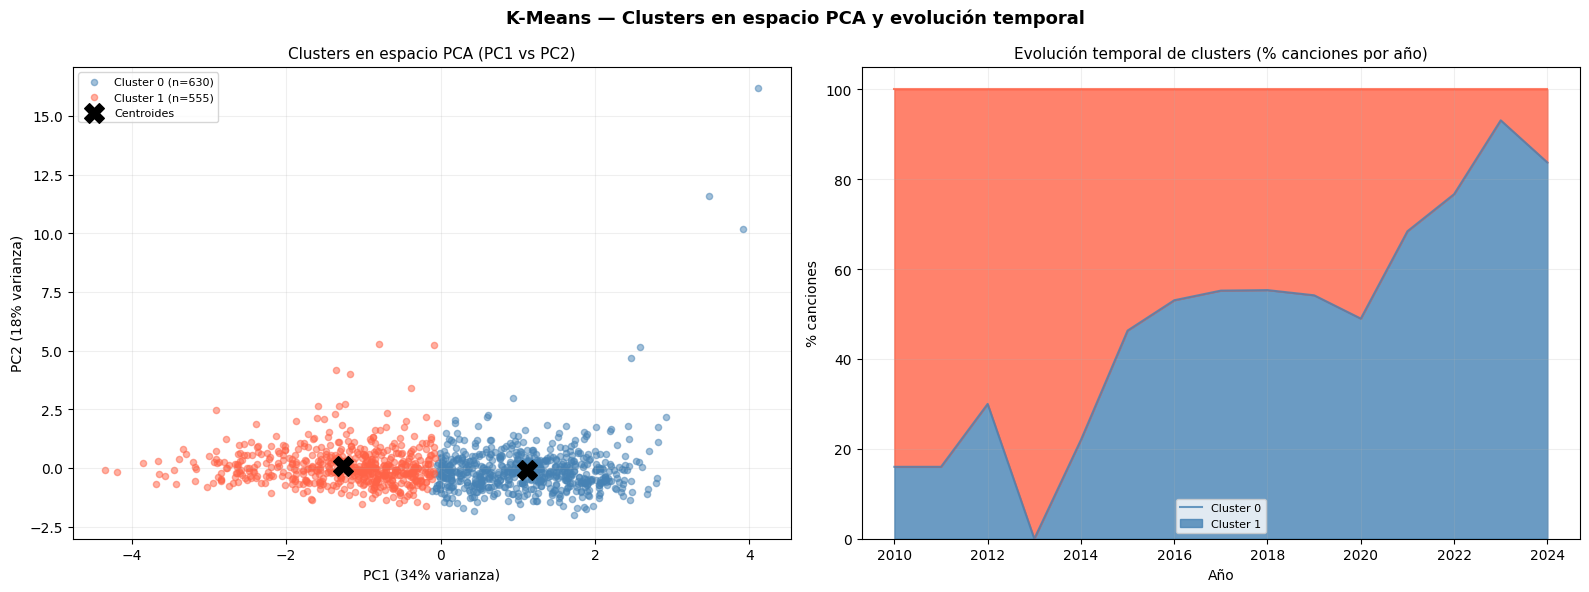

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means — Clusters en espacio PCA y evolución temporal', fontsize=13, fontweight='bold')

colors_cluster = COLORES_BASE[:K_FINAL]

for k in range(K_FINAL):
    mask = df_pca['cluster'] == k
    axes[0].scatter(
        df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
        label=f'Cluster {k} (n={mask.sum()})',
        alpha=0.5, s=20, color=colors_cluster[k]
    )

# Centroides
centroids_pca = pca_2d.transform(pca_kmeans.inverse_transform(kmeans_final.cluster_centers_))
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centroides')
axes[0].set_title('Clusters en espacio PCA (PC1 vs PC2)', fontsize=11)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.0%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.0%} varianza)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# Evolución temporal de clusters — área apilada coherente con Script 3
cluster_year = pd.crosstab(df['year'], df['cluster'])
cluster_year_pct = cluster_year.div(cluster_year.sum(axis=1), axis=0) * 100

cluster_year_pct.plot(
    kind='area', stacked=True, ax=axes[1],
    color=colors_cluster, alpha=0.8
)
axes[1].set_title('Evolución temporal de clusters (% canciones por año)', fontsize=11)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% canciones')
axes[1].legend([f'Cluster {k}' for k in range(K_FINAL)], fontsize=8)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 8. Interpretación de los clusters — Perfil sonoro

In [ ]:
# Añadimos cluster al dataset raw para interpretación
df_raw_cluster = df_raw.copy()
df_raw_cluster['cluster'] = cluster_labels

# Perfil estadístico de cada cluster
vars_perfil = ['popularity', 'duration_sec', 'artist_popularity', 'years_since_release']
vars_perfil_existentes = [v for v in vars_perfil if v in df_raw_cluster.columns]

perfil_clusters = df_raw_cluster.groupby('cluster')[vars_perfil_existentes].mean().round(2)
print('Perfil medio de cada cluster (variables originales, sin escalar):')
print(perfil_clusters.T)

# Género dominante por cluster
if 'genre_group_agrupado' in df_raw_cluster.columns:
    print('\nGénero dominante por cluster:')
    genero_cluster = df_raw_cluster.groupby('cluster')['genre_group_agrupado'].agg(
        lambda x: x.value_counts().index[0]
    )
    print(genero_cluster)

    print('\nDistribución completa de géneros por cluster (top 3):')
    for k in range(K_FINAL):
        mask = df_raw_cluster['cluster'] == k
        top3 = df_raw_cluster.loc[mask, 'genre_group_agrupado'].value_counts().head(3)
        print(f'  Cluster {k}: {dict(top3)}')

Perfil medio de cada cluster (variables originales, sin escalar):
cluster                   0       1
popularity            68.55   39.20
duration_sec         206.78  220.72
artist_popularity     78.43   52.99
years_since_release    0.37   -0.01


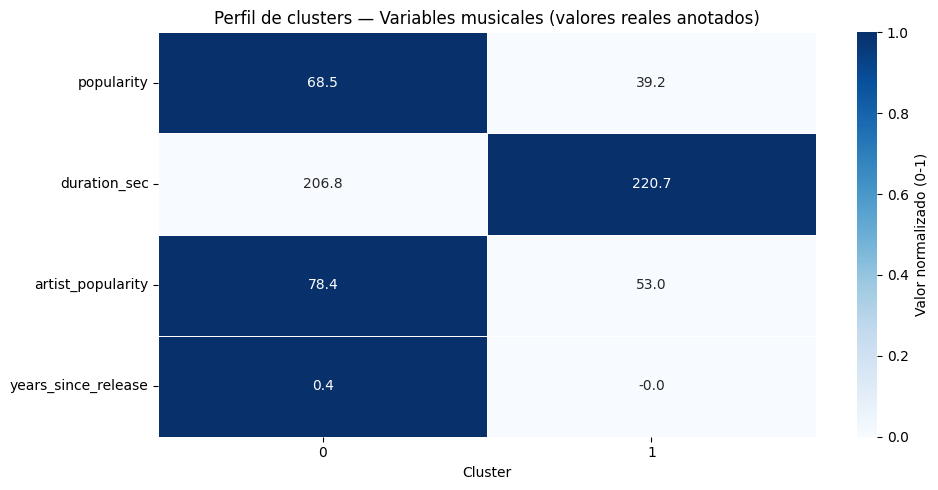

cluster,0,1
popularity,68.55,39.20
duration_sec,206.78,220.72
artist_popularity,78.43,52.99
years_since_release,0.37,-0.01


In [ ]:
# Heatmap de perfiles
perfil_norm = (perfil_clusters - perfil_clusters.min()) / (perfil_clusters.max() - perfil_clusters.min())

plt.figure(figsize=(10, 5))
sns.heatmap(perfil_norm.T, annot=perfil_clusters.T, fmt='.1f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Valor normalizado (0-1)'})
plt.title('Perfil de clusters — Variables musicales (valores reales anotados)', fontsize=12)
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# Tabla styled coherente con Scripts 1 y 2
perfil_clusters.T.style \
    .background_gradient(cmap='Blues') \
    .format(precision=2) \
    .set_caption('Perfil medio de cada cluster (valores sin escalar)') \
    .set_table_styles([
        {'selector': 'th.col_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'th.blank, th.index_name',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('padding-bottom', '8px'), ('text-align', 'center')]}
    ])

---
## 9. MÉTRICAS DE EVALUACIÓN — Resumen

In [ ]:
print('=' * 60)
print('RESUMEN DE MÉTRICAS DE EVALUACIÓN')
print('=' * 60)
print()
print('── PCA ──')
print(f'  Componentes para K-Means ({n_80}): varianza explicada = {sum(pca_kmeans.explained_variance_ratio_):.1%}')
print(f'  Componentes para visualización (2): varianza explicada = {sum(pca_2d.explained_variance_ratio_):.1%}')
print()
print('── K-Means ──')
print(f'  k final:             {K_FINAL}')
print(f'  Inercia:             {kmeans_final.inertia_:.2f}')
print(f'  Coeficiente Silueta: {sil_final:.4f}')
if sil_final > 0.5:
    interp = 'Clustering de buena calidad, clusters bien separados'
elif sil_final > 0.25:
    interp = 'Estructura razonable, algunos clusters solapados'
else:
    interp = 'Clusters débilmente separados (esperable en datos musicales continuos)'
print(f'  Interpretación:      {interp}')

# Tabla resumen styled
metricas = pd.DataFrame({
    'Modelo': ['PCA', 'PCA', 'K-Means', 'K-Means', 'K-Means'],
    'Métrica': ['Componentes (80% varianza)', 'Varianza explicada PC1+PC2',
                'k óptimo', 'Inercia', 'Coeficiente de Silueta'],
    'Valor': [str(n_80), f'{sum(pca_2d.explained_variance_ratio_):.1%}',
              str(K_FINAL), f'{kmeans_final.inertia_:.2f}', f'{sil_final:.4f}']
})

metricas.set_index('Modelo').style \
    .set_caption('Resumen de métricas — PCA + K-Means') \
    .set_table_styles([
        {'selector': 'th.col_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'th.blank, th.index_name',
         'props': [('background-color', '#1a3a5c'), ('color', 'white')]},
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('padding-bottom', '8px'), ('text-align', 'center')]}
    ])

RESUMEN DE MÉTRICAS DE EVALUACIÓN

── PCA ──
  Componentes para K-Means (6): varianza explicada = 83.0%
  Componentes para visualización (2): varianza explicada = 51.6%

── K-Means ──
  k final:             2
  Inercia:             4214.22
  Coeficiente Silueta: 0.2926
  Interpretación:      Estructura razonable, algunos clusters solapados


,Métrica,Valor
Modelo,,
PCA,Componentes (80% varianza),6
PCA,Varianza explicada PC1+PC2,51.6%
K-Means,k óptimo,2
K-Means,Inercia,4214.22
K-Means,Coeficiente de Silueta,0.2926


---
## 10. INTERPRETACIÓN Y CONCLUSIONES

In [ ]:
# Evolución anual de cada cluster para el análisis de tendencias
cluster_evol = df_raw_cluster.groupby(['year', 'cluster']).size().reset_index(name='n_canciones')
cluster_evol_pivot = cluster_evol.pivot(index='year', columns='cluster', values='n_canciones').fillna(0)

print('Canciones por cluster y año:')
print(cluster_evol_pivot.astype(int))

# Popularidad media por cluster y año
pop_cluster_year = df_raw_cluster.groupby(['year', 'cluster'])['popularity'].mean().round(1)
print('\nPopularidad media por cluster y año:')
print(pop_cluster_year.unstack())


Canciones por cluster y año:
cluster   0   1
year           
2010      8  42
2011      8  42
2012     15  35
2013      0  50
2014     11  39
2015     44  51
2016     52  46
2017     53  43
2018     52  42
2019     52  44
2020     48  50
2021     65  30
2022     69  21
2023     81   6
2024     72  14

Popularidad media por cluster y año:
cluster     0     1
year               
2010     62.4  37.5
2011     57.2  33.4
2012     62.5  35.3
2013      NaN  40.3
2014     62.7  37.7
2015     71.9  38.9
2016     72.9  38.3
2017     69.9  39.0
2018     66.1  40.9
2019     65.2  41.4
2020     63.5  31.7
2021     67.2  45.5
2022     69.8  47.4
2023     70.1  60.2
2024     72.3  56.2


---
## 11. GUARDADO

In [ ]:
# Dataset con clusters asignados (para usar en otros scripts)
df_raw_cluster.to_csv('dataset_canciones_clusters.csv', index=False)
print('✅ dataset_canciones_clusters.csv guardado')
print(f'   Filas: {len(df_raw_cluster)}')
print(f'   Columnas: {df_raw_cluster.shape[1]}')
print(f'   Clusters: {sorted(df_raw_cluster["cluster"].unique())}')

✅ dataset_canciones_clusters.csv guardado
   Filas: 1185
   Columnas: 17
   Clusters: [np.int32(0), np.int32(1)]
